# Copper-Scrap Feature Selection — self-contained

This notebook is **standalone**: it does **not** import `copper_feature_selection.py`.
All pipeline logic (fetch → engineer → screen → score → select → outputs) is
inlined in the cells below, and the correlation heatmap is **displayed inline**.

**Target:** COMEX copper front future (HG=F, $/lb) as a deep-history proxy for
the copper-scrap price (scrap ≈ COMEX × realization ratio), validated against
the ~24 real weekly yard points.

Run all cells top-to-bottom. Raw data pulls are cached under
`cache/copper_features_raw/`, so re-runs are fast and work offline.

## Imports, config & helpers

In [ ]:
%matplotlib inline
import io
import ssl
import sys
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

# ---- optional deps, degrade gracefully -------------------------------------
try:
    import certifi
    _SSL = ssl.create_default_context(cafile=certifi.where())
except Exception:
    _SSL = ssl.create_default_context()
try:
    import yfinance as yf
except Exception:
    yf = None
try:
    import matplotlib
    import matplotlib.pyplot as plt
except Exception:
    plt = None
try:
    import seaborn as sns
except Exception:
    sns = None
from scipy import stats as scipy_stats

# ===========================================================================
# Config
# ===========================================================================
START = "2015-01-01"
PROJECT = Path("/Users/gavinhussey/Downloads/rcm/scrapyard_project")
OUTDIR = PROJECT / "output" / "copper_features"
CACHE = PROJECT / "cache" / "copper_features_raw"
OUTDIR.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)
FREQ = "W-FRI"

LB_PER_TONNE = 2204.62

def log(msg: str) -> None:
    print(f"[copper-fs] {msg}", flush=True)

## 1. Fetchers (cached FRED + yfinance) and the feature spec

In [ ]:
def fetch_fred(series_id: str) -> pd.Series | None:
    cache = CACHE / f"fred_{series_id}.csv"
    if cache.exists():
        s = pd.read_csv(cache, index_col=0, parse_dates=True).iloc[:, 0]
        s.name = series_id
        return s
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    try:
        txt = urllib.request.urlopen(url, context=_SSL, timeout=20).read().decode()
        df = pd.read_csv(io.StringIO(txt))
        df.columns = ["date", "val"]
        df = df[df["val"] != "."].copy()
        df["date"] = pd.to_datetime(df["date"])
        df["val"] = pd.to_numeric(df["val"], errors="coerce")
        s = df.dropna().set_index("date")["val"]
        s = s[s.index >= pd.Timestamp(START)]
        s.name = series_id
        s.to_frame().to_csv(cache)
        log(f"FRED  {series_id:12s} ok ({len(s)} obs)")
        return s
    except Exception as exc:
        log(f"FRED  {series_id:12s} FAILED: {exc}")
        return None


def fetch_yf(ticker: str) -> pd.Series | None:
    safe = ticker.replace("=", "_").replace("^", "")
    cache = CACHE / f"yf_{safe}.csv"
    if cache.exists():
        s = pd.read_csv(cache, index_col=0, parse_dates=True).iloc[:, 0]
        s.name = ticker
        return s
    if yf is None:
        log(f"yf    {ticker:12s} skipped (yfinance not installed)")
        return None
    try:
        df = yf.download(ticker, start=START, progress=False, auto_adjust=True)
        if df is None or len(df) == 0:
            log(f"yf    {ticker:12s} EMPTY")
            return None
        close = df["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        s = pd.to_numeric(close, errors="coerce").dropna()
        s.index = pd.to_datetime(s.index)
        s.name = ticker
        s.to_frame().to_csv(cache)
        log(f"yf    {ticker:12s} ok ({len(s)} obs)")
        return s
    except Exception as exc:
        log(f"yf    {ticker:12s} FAILED: {exc}")
        return None


# (raw_name, fetcher, source_id, friendly_name, category, units, stationary?)
#   stationary=True  -> screen on LEVELS (rates, spreads, ratios, indices)
#   stationary=False -> screen on weekly RETURNS (price series; levels are
#                       non-stationary so level-correlations are spurious)
SPEC = [
    ("comex_copper",      "yf",   "HG=F",        "COMEX copper front ($/lb)",     "copper_price", "usd_lb",    False),
    ("copper_etf",        "yf",   "CPER",        "US Copper ETF (CPER)",          "copper_price", "usd",       False),
    ("lme_copper",        "fred", "PCOPPUSDM",   "Global/LME copper ($/tonne,M)", "copper_price", "usd_tonne", False),
    ("aluminum",          "yf",   "ALI=F",       "COMEX aluminum front",          "copper_price", "usd_tonne", False),
    ("wti_oil",           "fred", "DCOILWTICO",  "WTI crude oil ($/bbl)",         "energy_cost",  "usd_bbl",   False),
    ("brent_oil",         "fred", "DCOILBRENTEU","Brent crude oil ($/bbl)",       "energy_cost",  "usd_bbl",   False),
    ("diesel",            "fred", "GASDESW",     "US diesel retail ($/gal,W)",    "energy_cost",  "usd_gal",   False),
    ("dxy",               "fred", "DTWEXBGS",    "Trade-weighted USD (broad)",    "financial",    "index",     False),
    ("ust_10y",           "fred", "DGS10",       "UST 10y yield (%)",             "financial",    "pct",       True),
    ("ust_2y",            "fred", "DGS2",        "UST 2y yield (%)",              "financial",    "pct",       True),
    ("yield_curve_2s10s", "fred", "T10Y2Y",      "10y-2y curve slope (%)",        "financial",    "pct",       True),
    ("fed_funds",         "fred", "DFF",         "Fed funds effective (%)",       "financial",    "pct",       True),
    ("vix",               "fred", "VIXCLS",      "VIX equity volatility",         "financial",    "index",     True),
    # macro indices: slow-moving levels analysts track vs copper -> screen on
    # LEVELS (with a common-trend caveat); change versions added in engineer().
    ("indpro",            "fred", "INDPRO",      "Industrial production (M)",      "macro_demand", "index",     True),
    ("ip_manufacturing",  "fred", "IPMAN",       "IP manufacturing (M)",          "macro_demand", "index",     True),
    ("housing_starts",    "fred", "HOUST",       "Housing starts (M)",            "macro_demand", "kunits",    True),
    ("construction_spend","fred", "TTLCONS",     "Construction spending (M)",     "macro_demand", "usd_mm",    True),
    ("mfg_new_orders",    "fred", "AMTMNO",      "Mfg new orders (M)",            "macro_demand", "usd_mm",    True),
    ("mfg_employment",    "fred", "MANEMP",      "Mfg employment (M)",            "macro_demand", "kpersons",  True),
    ("ppi_steel",         "fred", "WPU101",      "PPI iron & steel (M)",          "macro_demand", "index",     True),
    ("ppi_allcommod",     "fred", "PPIACO",      "PPI all commodities (M)",       "macro_demand", "index",     True),
]

CATEGORY_BONUS = {
    "copper_price": 0.30, "tightness": 0.30, "energy_cost": 0.20,
    "macro_demand": 0.25, "financial": 0.15, "engineered": 0.20,
}
# caps for the final balanced batch (per the requested composition)
CATEGORY_CAPS = {
    "copper_price": 4, "tightness": 3, "macro_demand": 3,
    "financial": 3, "energy_cost": 3, "engineered": 5,
}

## 2. Load & clean the raw panel

In [ ]:
def load_raw() -> tuple[pd.DataFrame, dict, list]:
    log("=== STEP 1: loading raw series ===")
    series, meta, dropped = {}, {}, []
    for raw, kind, sid, friendly, cat, units, stat in SPEC:
        s = fetch_yf(sid) if kind == "yf" else fetch_fred(sid)
        if s is None or s.dropna().empty:
            dropped.append((raw, "fetch failed / empty"))
            continue
        s = s[~s.index.duplicated(keep="last")].sort_index()
        series[raw] = s
        meta[raw] = dict(source=f"{kind}:{sid}", friendly=friendly,
                         category=cat, units=units, stationary=stat)
    raw_df = pd.DataFrame(series).sort_index()
    raw_df.to_csv(OUTDIR / "raw_copper_panel.csv")
    log(f"loaded {raw_df.shape[1]} raw series, {raw_df.shape[0]} daily rows")
    return raw_df, meta, dropped


def to_weekly(raw_df: pd.DataFrame, meta: dict) -> pd.DataFrame:
    """Resample to a weekly Friday grid. Daily price series -> last obs of the
    week; monthly macro -> forward-filled (no look-ahead: a month's value is
    only carried forward, never backward)."""
    wk = raw_df.resample(FREQ).last()
    # forward-fill monthly/weekly macro across the weekly grid (bounded)
    monthlyish = [c for c in wk.columns
                  if raw_df[c].dropna().index.to_series().diff().dt.days.median() > 10]
    wk[monthlyish] = wk[monthlyish].ffill(limit=8)
    wk = wk.ffill(limit=2)
    return wk


def load_real_scrap() -> pd.Series | None:
    """The genuine ~24-point weekly yard copper scrap price (for validation)."""
    p = PROJECT / "output" / "sell_signal" / "cleaned_price_data.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p, index_col=0, parse_dates=True)
    if "COPPER" not in d.columns:
        return None
    return d["COPPER"].dropna()

## 3. Feature engineering (no look-ahead)

In [4]:
def engineer(wk: pd.DataFrame, meta: dict) -> tuple[pd.DataFrame, dict]:
    log("=== STEP 2: engineering features ===")
    feat = pd.DataFrame(index=wk.index)
    fmeta: dict[str, dict] = {}

    def add(name, series, category, friendly, stationary, kind="engineered"):
        feat[name] = series
        fmeta[name] = dict(category=category, friendly=friendly,
                           stationary=stationary, kind=kind)

    # -- raw levels carried through as candidate features --------------------
    for raw, m in meta.items():
        if raw in wk.columns:
            add(raw, wk[raw], m["category"], m["friendly"], m["stationary"],
                kind="raw")

    cu = wk.get("comex_copper")

    # -- direct copper relationships ----------------------------------------
    if "comex_copper" in wk and "lme_copper" in wk:
        # both to $/tonne, COMEX-LME arbitrage spread (tightness/location signal)
        comex_t = wk["comex_copper"] * LB_PER_TONNE
        add("comex_lme_spread", comex_t - wk["lme_copper"], "tightness",
            "COMEX-LME copper spread ($/tonne)", True)
        add("comex_lme_ratio", comex_t / wk["lme_copper"], "tightness",
            "COMEX/LME copper ratio", True)
    if "comex_copper" in wk and "copper_etf" in wk:
        add("copper_etf_basis", (wk["copper_etf"] / wk["copper_etf"].iloc[:20].mean())
            - (wk["comex_copper"] / wk["comex_copper"].iloc[:20].mean()),
            "tightness", "Copper ETF vs COMEX rebased gap", True)

    # -- momentum (pct change over 1/4/13 weeks ~ 7/30/90 day equivalents) ---
    if cu is not None:
        for n, lbl in [(1, "7d"), (4, "30d"), (13, "90d")]:
            add(f"cu_momentum_{lbl}", cu.pct_change(n), "engineered",
                f"COMEX copper {lbl} momentum", False)
        # rolling averages (price level smoothing) and price-vs-MA
        for n, lbl in [(4, "30d"), (13, "90d")]:
            ma = cu.rolling(n, min_periods=max(2, n // 2)).mean()
            add(f"cu_ma_{lbl}", ma, "copper_price", f"COMEX copper {lbl} avg", False)
            add(f"cu_vs_ma_{lbl}", cu / ma - 1.0, "engineered",
                f"COMEX copper vs {lbl} avg", True)
        # rolling realized volatility of weekly returns
        ret = cu.pct_change()
        for n, lbl in [(4, "30d"), (13, "90d")]:
            add(f"cu_vol_{lbl}", ret.rolling(n, min_periods=max(2, n // 2)).std(),
                "engineered", f"COMEX copper {lbl} volatility", True)
        # lagged copper price (descriptive; flagged as autocorrelated w/ target)
        for n, lbl in [(1, "7d"), (4, "30d"), (13, "90d")]:
            add(f"cu_lag_{lbl}", cu.shift(n), "copper_price",
                f"COMEX copper lagged {lbl}", False)

    # -- macro: level + change versions -------------------------------------
    change_specs = {
        "dxy": ("financial", "USD broad"), "wti_oil": ("energy_cost", "WTI"),
        "diesel": ("energy_cost", "diesel"), "indpro": ("macro_demand", "IP"),
        "ip_manufacturing": ("macro_demand", "IP mfg"),
        "housing_starts": ("macro_demand", "housing starts"),
        "construction_spend": ("macro_demand", "construction"),
        "mfg_new_orders": ("macro_demand", "mfg new orders"),
        "ppi_steel": ("macro_demand", "PPI steel"),
        "vix": ("financial", "VIX"),
    }
    for col, (cat, nm) in change_specs.items():
        if col in wk:
            add(f"{col}_chg_30d", wk[col].pct_change(4), cat,
                f"{nm} 30d change", False)
    # yields: absolute change (already %), not pct
    for col in ["ust_10y", "ust_2y", "yield_curve_2s10s", "fed_funds"]:
        if col in wk:
            add(f"{col}_chg_30d", wk[col].diff(4), "financial",
                f"{col} 30d change", True)

    feat = feat.replace([np.inf, -np.inf], np.nan)
    n_raw = sum(1 for m in fmeta.values() if m["kind"] == "raw")
    log(f"built {feat.shape[1]} candidate features "
        f"({n_raw} raw + {feat.shape[1]-n_raw} engineered)")
    return feat, fmeta

## 4. Screening (Pearson/Spearman, levels & changes, lags, stability)

In [5]:
def _corr_pair(x: pd.Series, y: pd.Series):
    df = pd.concat([x, y], axis=1).dropna()
    if len(df) < 24:
        return np.nan, np.nan, len(df)
    a, b = df.iloc[:, 0], df.iloc[:, 1]
    if a.std() == 0 or b.std() == 0:
        return np.nan, np.nan, len(df)
    p = scipy_stats.pearsonr(a, b)[0]
    s = scipy_stats.spearmanr(a, b)[0]
    return p, s, len(df)


def screen(feat: pd.DataFrame, fmeta: dict, target_col: str) -> pd.DataFrame:
    log("=== STEP 3: screening features vs target ===")
    tgt_level = feat[target_col]
    tgt_ret = tgt_level.pct_change()
    n = len(feat)
    rows = []
    for col in feat.columns:
        if col == target_col:
            continue
        m = fmeta[col]
        s = feat[col]
        miss = s.isna().mean()
        p_lvl, sp_lvl, n_lvl = _corr_pair(s, tgt_level)
        # change-based: pct-change for price-like, diff for already-% series
        chg = s.diff() if m["stationary"] else s.pct_change()
        p_chg, sp_chg, n_chg = _corr_pair(chg.replace([np.inf, -np.inf], np.nan),
                                          tgt_ret)
        # appropriate screen correlation: levels for stationary, returns for prices
        if m["stationary"]:
            screen_p, screen_s, screen_n = p_lvl, sp_lvl, n_lvl
            screen_kind = "level"
        else:
            screen_p, screen_s, screen_n = p_chg, sp_chg, n_chg
            screen_kind = "change"
        # best lag (1/4/13 wk) on the screen transform -> max |pearson|
        base = s if m["stationary"] else chg
        tgt_for_lag = tgt_level if m["stationary"] else tgt_ret
        best_lag, best_lag_corr = 0, screen_p
        for lag in (1, 4, 13):
            pl, _, _ = _corr_pair(base.shift(lag), tgt_for_lag)
            if not np.isnan(pl) and abs(pl) > abs(best_lag_corr or 0):
                best_lag, best_lag_corr = lag, pl
        # stability across two halves of the sample
        half = n // 2
        p1, _, _ = _corr_pair(base.iloc[:half], tgt_for_lag.iloc[:half])
        p2, _, _ = _corr_pair(base.iloc[half:], tgt_for_lag.iloc[half:])
        if np.isnan(p1) or np.isnan(p2):
            stability = np.nan
        else:
            stability = 1.0 - min(1.0, abs(p1 - p2) / 1.0)
        rows.append(dict(
            feature=col, category=m["category"], kind=m["kind"],
            friendly=m["friendly"], screen_kind=screen_kind,
            pearson_level=p_lvl, spearman_level=sp_lvl,
            pearson_change=p_chg, spearman_change=sp_chg,
            screen_pearson=screen_p, screen_spearman=screen_s,
            best_lag_wk=best_lag, best_lag_pearson=best_lag_corr,
            stability=stability, missing_frac=miss, n_obs=screen_n,
            abs_screen=np.nanmax([abs(screen_p or np.nan),
                                  abs(screen_s or np.nan)]),
        ))
    rank = pd.DataFrame(rows).sort_values("abs_screen", ascending=False,
                                          na_position="last").reset_index(drop=True)
    rank.to_csv(OUTDIR / "feature_correlation_rankings.csv", index=False)
    log(f"ranked {len(rank)} features (top |corr|="
        f"{rank['abs_screen'].iloc[0]:.3f})")
    return rank

## 5. Scoring + redundancy-aware, category-balanced selection

In [6]:
def score_table(rank: pd.DataFrame) -> pd.DataFrame:
    r = rank.copy()
    r["abs_screen"] = r["abs_screen"].fillna(0)
    r["stability"] = r["stability"].fillna(0.5)
    r["score"] = (
        0.55 * r["abs_screen"]
        + 0.15 * r["best_lag_pearson"].abs().fillna(0)
        + 0.15 * r["stability"]
        - 0.40 * r["missing_frac"]
        + r["category"].map(CATEGORY_BONUS).fillna(0.10)
    )
    return r.sort_values("score", ascending=False).reset_index(drop=True)


def select(feat: pd.DataFrame, scored: pd.DataFrame, target_col: str,
           corr_min: float, redun: float, max_n: int = 18) -> list[str]:
    """Greedy, category-capped selection with redundancy pruning."""
    chosen: list[str] = []
    cat_count: dict[str, int] = {}
    cand = scored[scored["abs_screen"] >= corr_min]
    for _, row in cand.iterrows():
        f = row["feature"]
        cat = row["category"]
        if cat_count.get(cat, 0) >= CATEGORY_CAPS.get(cat, 3):
            continue
        # redundancy vs already-chosen (Pearson on aligned levels)
        redundant = False
        for c in chosen:
            d = pd.concat([feat[f], feat[c]], axis=1).dropna()
            if len(d) >= 24 and d.iloc[:, 0].std() and d.iloc[:, 1].std():
                if abs(d.corr().iloc[0, 1]) >= redun:
                    redundant = True
                    break
        if redundant:
            continue
        chosen.append(f)
        cat_count[cat] = cat_count.get(cat, 0) + 1
        if len(chosen) >= max_n:
            break
    return chosen


def sweep(feat, scored, target_col):
    log("=== STEP 4-5: threshold sweep + selection ===")
    results = []
    for cm in (0.10, 0.20):
        for rd in (0.85, 0.90):
            sel = select(feat, scored, target_col, cm, rd)
            cats = scored.set_index("feature").loc[sel, "category"]
            balanced = cats.nunique()
            results.append(dict(corr_min=cm, redun=rd, n=len(sel),
                                categories=balanced, features=sel))
            log(f"  corr_min={cm} redun={rd}: {len(sel)} feats, "
                f"{balanced} categories")
    # choose: prefer 10-20 features AND maximum category diversity, then count
    def quality(r):
        in_range = 10 <= r["n"] <= 20
        return (in_range, r["categories"], min(r["n"], 18))
    best = max(results, key=quality)
    log(f"  -> chosen: corr_min={best['corr_min']} redun={best['redun']} "
        f"({best['n']} features, {best['categories']} categories)")
    return best, results

## 6. Output writers (CSVs, summary.md, heatmap)

In [7]:
def write_outputs(feat, scored, sel, target_col, meta, fmeta, dropped,
                  raw_df, wk, real_scrap, best, sweep_results):
    log("=== STEP 6: writing outputs ===")
    cols = [target_col] + sel

    # cleaned feature panel
    feat.to_csv(OUTDIR / "cleaned_copper_features.csv")

    # selected features + their correlations
    sel_tbl = scored.set_index("feature").loc[sel].reset_index()
    sel_tbl.to_csv(OUTDIR / "selected_correlation_features.csv", index=False)

    # correlation matrix of target + selected (Pearson on aligned data)
    cm = feat[cols].corr()
    cm.to_csv(OUTDIR / "copper_scrap_correlation_matrix.csv")

    # heatmap
    if plt is not None:
        fig, ax = plt.subplots(figsize=(min(20, 1.0 + 0.7 * len(cols)),
                                        min(18, 1.0 + 0.6 * len(cols))))
        if sns is not None:
            sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                        vmin=-1, vmax=1, square=True, ax=ax,
                        cbar_kws={"shrink": .8}, annot_kws={"size": 7})
        else:
            im = ax.imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1)
            ax.set_xticks(range(len(cols)))
            ax.set_xticklabels(cols, rotation=90, fontsize=7)
            ax.set_yticks(range(len(cols)))
            ax.set_yticklabels(cols, fontsize=7)
            for i in range(len(cols)):
                for j in range(len(cols)):
                    v = cm.values[i, j]
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            fontsize=6,
                            color="white" if abs(v) > 0.55 else "black")
            fig.colorbar(im, shrink=.8)
        ax.set_title("Copper-scrap (COMEX proxy) correlation matrix")
        fig.tight_layout()
        fig.savefig(OUTDIR / "copper_scrap_correlation_heatmap.png", dpi=150)
        plt.close(fig)

    # ---- realization-ratio validation against the 24 real yard points ------
    realz = None
    if real_scrap is not None and target_col == "comex_copper":
        j = pd.concat([real_scrap.rename("yard_scrap"),
                       wk["comex_copper"].rename("comex")], axis=1).dropna()
        if len(j):
            j["realization"] = j["yard_scrap"] / j["comex"]
            j.to_csv(OUTDIR / "scrap_realization_validation.csv")
            realz = j["realization"]

    write_summary(scored, sel, target_col, meta, fmeta, dropped, raw_df, wk,
                  feat, cm, realz, best, sweep_results)
    log(f"all outputs written to {OUTDIR}")


def write_summary(scored, sel, target_col, meta, fmeta, dropped, raw_df, wk,
                  feat, cm, realz, best, sweep_results):
    sset = scored.set_index("feature")
    lines = []
    A = lines.append
    A("# Copper-Scrap Feature-Selection Summary\n")
    A(f"*Generated by `copper_feature_selection.py`.*\n")

    A("## Target variable\n")
    A(f"- **{target_col}** — COMEX copper front future (HG=F, $/lb), used as a "
      "deep-history **proxy for the copper-scrap price** (scrap ~= COMEX x "
      "realization ratio).")
    if realz is not None and len(realz):
        A(f"- Validated against {len(realz)} real weekly yard scrap points: "
          f"realization ratio mean **{realz.mean():.3f}** "
          f"(min {realz.min():.3f}, max {realz.max():.3f}), i.e. yard copper "
          f"scrap realized ~{realz.mean()*100:.0f}% of COMEX over 2026 H1.")
    A("")

    dr = feat.dropna(how="all")
    A("## Data range & counts\n")
    A(f"- Weekly grid ({FREQ}): **{dr.index.min().date()} -> "
      f"{dr.index.max().date()}** ({len(dr)} weeks).")
    n_raw = sum(1 for m in fmeta.values() if m["kind"] == "raw")
    A(f"- Original raw series fetched: **{raw_df.shape[1]}**")
    A(f"- Candidate features after engineering: **{feat.shape[1]-1}** "
      f"({n_raw-1} raw levels + {feat.shape[1]-n_raw} engineered).")
    A(f"- Final selected features: **{len(sel)}**.\n")

    A("## Threshold sweep (multiple thresholds compared)\n")
    A("| corr_min | redundancy | #features | #categories |")
    A("|---|---|---|---|")
    for r in sweep_results:
        star = "  <- chosen" if (r["corr_min"], r["redun"]) == \
            (best["corr_min"], best["redun"]) else ""
        A(f"| {r['corr_min']:.2f} | {r['redun']:.2f} | {r['n']} | "
          f"{r['categories']}{star} |")
    A(f"\nChosen combination: **corr_min={best['corr_min']}, "
      f"redundancy={best['redun']}** — it lands in the 10-20 target band with "
      "the broadest economic-category coverage.\n")

    A("## Final selected features\n")
    A("| # | feature | category | screen |corr| | best lag (wk) | stability | "
      "missing | why included |")
    A("|---|---|---|---|---|---|---|---|")
    reasons = {
        "copper_price": "direct copper price level — primary scrap-price driver",
        "tightness": "market-tightness / arbitrage signal (inventory proxy)",
        "macro_demand": "downstream copper demand driver",
        "financial": "macro-financial pricing factor (USD/rates/risk)",
        "energy_cost": "freight/energy input cost & reflation signal",
        "engineered": "copper price dynamics (momentum/vol/MA)",
    }
    for i, f in enumerate(sel, 1):
        r = sset.loc[f]
        A(f"| {i} | `{f}` | {r['category']} | {r['abs_screen']:.3f} | "
          f"{int(r['best_lag_wk'])} | {r['stability']:.2f} | "
          f"{r['missing_frac']*100:.0f}% | {reasons.get(r['category'],'')} |")
    A("")

    A("## Correlation of each selected feature with the target\n")
    tcorr = cm[target_col].drop(target_col).sort_values(key=abs, ascending=False)
    for f, v in tcorr.items():
        A(f"- `{f}`: {v:+.3f}")
    A("")

    A("## Features rejected due to redundancy\n")
    chosen_set = set(sel)
    redun_notes = []
    for f in scored["feature"]:
        if f in chosen_set:
            continue
        # find which selected feature it was too similar to
        for c in sel:
            d = pd.concat([feat[f], feat[c]], axis=1).dropna()
            if len(d) >= 24 and d.iloc[:, 0].std() and d.iloc[:, 1].std():
                rr = abs(d.corr().iloc[0, 1])
                if rr >= best["redun"]:
                    redun_notes.append(f"- `{f}` dropped (|r|={rr:.2f} with "
                                       f"kept `{c}`)")
                    break
    A("\n".join(redun_notes[:25]) if redun_notes else "- (none)")
    A("")

    A("## Features rejected due to missing data\n")
    miss = scored[scored["missing_frac"] > 0.5]
    if len(miss):
        for _, r in miss.iterrows():
            A(f"- `{r['feature']}` ({r['missing_frac']*100:.0f}% missing)")
    else:
        A("- (none exceeded the 50% missing threshold)")
    A("")

    A("## Dropped raw series & why\n")
    if dropped:
        for nm, why in dropped:
            A(f"- `{nm}`: {why}")
    else:
        A("- (all requested raw series fetched successfully)")
    A("")

    A("## Data-quality warnings\n")
    A("- **No free copper-inventory series** (LME/COMEX warehouse stocks are "
      "paywalled). Tightness is proxied by the **COMEX-LME spread/ratio** and "
      "the ETF-vs-COMEX basis instead. Add LME/COMEX stocks or the Yangshan "
      "premium when a feed is available.")
    A("- **ISM/China PMI** are not on the free FRED endpoint; manufacturing "
      "demand is proxied by INDPRO / IP-manufacturing / mfg-new-orders / "
      "mfg-employment.")
    A("- Macro-demand indices (new-orders, construction, PPI, IP, housing) are "
      "screened on **levels**; copper and these indices share a secular uptrend, "
      "so part of the strong level correlation is **common trend**, not pure "
      "demand signal. Their first-difference (`*_chg_30d`) versions are also "
      "provided and are far more weakly correlated — treat the level features "
      "as co-movement context, not clean causal drivers.")
    A("- Monthly macro series are **forward-filled** onto the weekly grid "
      "(carried forward only — no look-ahead). Their effective information "
      "frequency is monthly.")
    A("- Copper own-momentum / lagged-copper features are **autocorrelated "
      "with the target by construction**; they are useful descriptors for the "
      "matrix but should not be read as independent predictive edge.")
    A("- The genuine yard scrap price is only ~24 weekly points (2026 H1); it "
      "is used for realization-ratio validation, not as the screening target.")
    A("")

    A("## Recommended next steps\n")
    A("1. Acquire a copper-inventory / tightness feed (LME+COMEX+SHFE stocks, "
      "Yangshan premium) — likely the single biggest missing signal.")
    A("2. Model copper scrap as `COMEX x realization_ratio`; model the "
      "realization ratio separately against the tightness & macro features.")
    A("3. As yard scrap history grows past ~52 weeks, re-run this screen with "
      "the real scrap series as the direct target and compare.")
    A("4. Use the selected batch in a regularized / tree model with the lagged "
      "versions to test genuine predictive (not contemporaneous) power.")
    A("5. Add COMEX futures-curve slope (front vs deferred) once a multi-tenor "
      "feed is available — a known copper-cycle signal.")

    (OUTDIR / "feature_selection_summary.md").write_text("\n".join(lines))

## 7. Run the pipeline

In [8]:
TARGET = "comex_copper"
raw_df, meta, dropped = load_raw()
wk = to_weekly(raw_df, meta)
real_scrap = load_real_scrap()
feat, fmeta = engineer(wk, meta)
rank = screen(feat, fmeta, TARGET)
scored = score_table(rank)
scored.to_csv(OUTDIR / "feature_scores.csv", index=False)
best, sweep_results = sweep(feat, scored, TARGET)
sel = best["features"]
print("\nChosen: corr_min=%(corr_min)s redundancy=%(redun)s -> %(n)d features"
      % best)
sel

[copper-fs] === STEP 1: loading raw series ===


[copper-fs] loaded 21 raw series, 4190 daily rows


[copper-fs] === STEP 2: engineering features ===


[copper-fs] built 50 candidate features (21 raw + 29 engineered)


[copper-fs] === STEP 3: screening features vs target ===


...

[copper-fs]   corr_min=0.2 redun=0.85: 12 feats, 6 categories


[copper-fs]   corr_min=0.2 redun=0.9: 13 feats, 6 categories


[copper-fs]   -> chosen: corr_min=0.1 redun=0.9 (15 features, 6 categories)



Chosen: corr_min=0.1 redundancy=0.9 -> 15 features


['copper_etf',
 'copper_etf_basis',
 'mfg_new_orders',
 'ppi_steel',
 'aluminum',
 'housing_starts',
 'ust_10y',
 'comex_lme_spread',
 'fed_funds',
 'dxy',
 'cu_vs_ma_90d',
 'wti_oil',
 'cu_vol_90d',
 'cu_vs_ma_30d',
 'cu_vol_30d']

### Threshold sweep that was compared

In [9]:
pd.DataFrame(sweep_results)[["corr_min", "redun", "n", "categories"]]

,corr_min,redun,n,categories
0,0.1,0.85,14,6
1,0.1,0.90,15,6
2,0.2,0.85,12,6
3,0.2,0.90,13,6


### Selected features (screen stats)

In [10]:
scored.set_index("feature").loc[sel, ["category", "abs_screen", "best_lag_wk", "stability", "missing_frac"]].round(3)

,category,abs_screen,best_lag_wk,stability,missing_frac
feature,,,,,
copper_etf,copper_price,0.963,0,0.927,0.000
copper_etf_basis,tightness,0.885,0,0.863,0.000
mfg_new_orders,macro_demand,0.882,0,0.954,0.003
ppi_steel,macro_demand,0.843,0,0.557,0.000
aluminum,copper_price,0.466,0,0.774,0.002
housing_starts,macro_demand,0.617,13,0.412,0.000
ust_10y,financial,0.602,0,0.941,0.000
comex_lme_spread,tightness,0.402,0,0.805,0.000
fed_funds,financial,0.533,0,0.601,0.000


## 8. Write the deliverable files (CSVs, summary.md, heatmap.png)

In [11]:
write_outputs(feat, scored, sel, TARGET, meta, fmeta, dropped,
              raw_df, wk, real_scrap, best, sweep_results)
print("deliverables written to", OUTDIR)

[copper-fs] === STEP 6: writing outputs ===


[copper-fs] all outputs written to /Users/gavinhussey/Downloads/rcm/scrapyard_project/output/copper_features


deliverables written to /Users/gavinhussey/Downloads/rcm/scrapyard_project/output/copper_features


/var/folders/jw/68qy1nm53wd8tszy8vwhv7480000gn/T/ipykernel_17634/3941196167.py:46: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([real_scrap.rename("yard_scrap"),


## 9. Correlation matrix + heatmap (displayed inline)

In [12]:
cols = [TARGET] + sel
order = [TARGET] + (feat[cols].corr()[TARGET].drop(TARGET)
                    .abs().sort_values(ascending=False).index.tolist())
cm = feat[order].corr().loc[order, order]
cm[TARGET].round(3)

comex_copper        1.000
copper_etf          0.997
copper_etf_basis   -0.885
mfg_new_orders      0.882
aluminum            0.864
ppi_steel           0.807
wti_oil             0.674
ust_10y             0.602
fed_funds           0.533
housing_starts      0.504
dxy                 0.479
comex_lme_spread    0.402
cu_vol_90d          0.298
cu_vs_ma_90d        0.272
cu_vol_30d          0.174
cu_vs_ma_30d        0.151
Name: comex_copper, dtype: float64

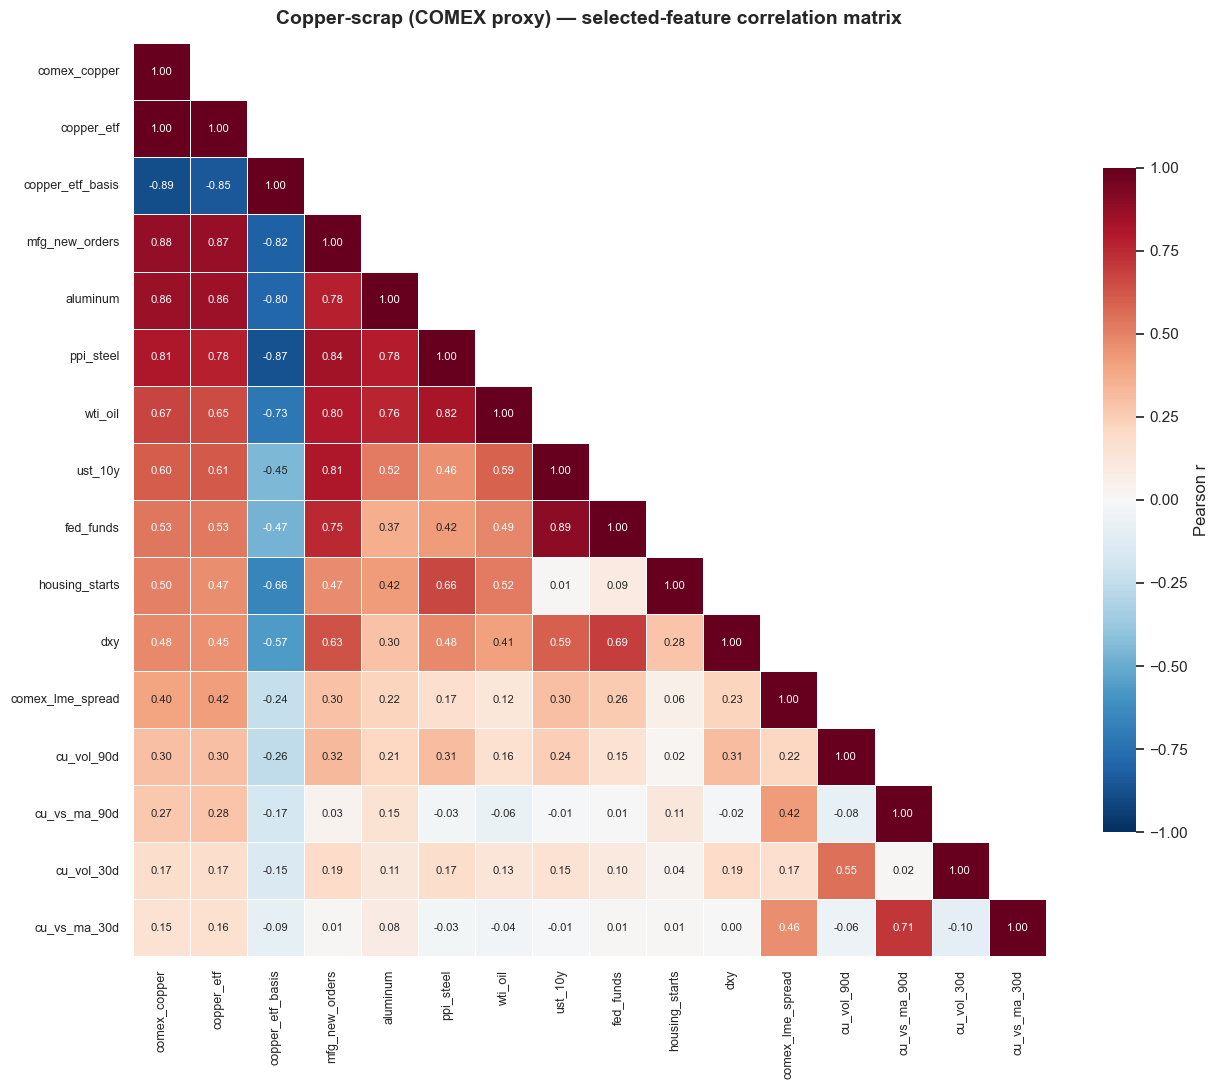

In [13]:
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, linecolor="white",
            cbar_kws={"shrink": .7, "label": "Pearson r"},
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Copper-scrap (COMEX proxy) — selected-feature correlation matrix",
             fontsize=14, pad=14, weight="bold")
ax.tick_params(axis="x", labelrotation=90, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
fig.tight_layout()
fig.savefig(OUTDIR / "copper_scrap_correlation_heatmap.png",
            dpi=160, bbox_inches="tight")
from IPython.display import display
display(fig)
plt.close(fig)

## 10. Realization-ratio validation (real yard scrap vs COMEX)

In [14]:
j = pd.concat([real_scrap.rename("yard_scrap"),
                wk["comex_copper"].rename("comex")], axis=1).dropna()
j["realization"] = j["yard_scrap"] / j["comex"]
print(f"Yard copper scrap realized {j['realization'].mean()*100:.0f}% of COMEX "
      f"(min {j['realization'].min():.2f}, max {j['realization'].max():.2f}, "
      f"n={len(j)})")
j.tail(5).round(3)

Yard copper scrap realized 64% of COMEX (min 0.51, max 0.77, n=24)


/var/folders/jw/68qy1nm53wd8tszy8vwhv7480000gn/T/ipykernel_17634/1267711399.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([real_scrap.rename("yard_scrap"),


,yard_scrap,comex,realization
2026-05-22,3.787,6.342,0.597
2026-05-29,3.759,6.359,0.591
2026-06-05,4.265,6.264,0.681
2026-06-12,4.355,6.431,0.677
2026-06-19,3.764,6.374,0.590
